In [60]:
import pandas as pd
import numpy as np

# ============================
# STEP 3A — PART 1: Load Data & Promotions Flag (explicit MDY/DMY rules)
# ============================

print("🚀 STEP 3A — PART 1: Load Data & Promotions Flag (explicit MDY/DMY rules)")
print("="*78)

# ---- 1) Load CSVs ----
sales  = pd.read_csv("Assignment4.1a.csv")
promos = pd.read_csv("Promotiondates.csv")

print(f"✓ Sales: {sales.shape[0]} rows | Columns: {list(sales.columns)}")
print(f"✓ Promotions: {promos.shape[0]} rows | Columns: {list(promos.columns)}")

# ---- 2) Sales tarihleri ----
sales["Date"] = pd.to_datetime(sales["Date"], errors="coerce")
sales = sales.dropna(subset=["Date"]).reset_index(drop=True)

# ---- 3) Period kolonunu garanti et ----
if "Period" not in promos.columns:
    promos = promos.copy()
    promos["Period"] = [f"Promo{i}" for i in range(1, len(promos) + 1)]

# ---- 4) P1–P4 = MDY, P5–P6 = DMY (explicit) ----
period_str = promos["Period"].astype(str)
is_p56 = period_str.str.contains(r"Promo5|Promo6", case=False) | period_str.str.fullmatch(r"[56]")

def parse_with(series, dayfirst=False):
    return pd.to_datetime(series, errors="coerce", dayfirst=dayfirst)

# P1–P4: MDY
promos.loc[~is_p56, "StartDate"] = parse_with(promos.loc[~is_p56, "StartDate"], dayfirst=False)
promos.loc[~is_p56, "EndDate"]   = parse_with(promos.loc[~is_p56, "EndDate"],   dayfirst=False)

# P5–P6: DMY
promos.loc[is_p56, "StartDate"] = parse_with(promos.loc[is_p56, "StartDate"], dayfirst=True)
promos.loc[is_p56, "EndDate"]   = parse_with(promos.loc[is_p56, "EndDate"],   dayfirst=True)

# ---- 5) Kalite kontrolleri ----
# a) Parse edilemeyen satırlar
bad = promos["StartDate"].isna() | promos["EndDate"].isna()
if bad.any():
    print("⚠️ Unparseable promo dates, dropping rows:")
    print(promos.loc[bad, ["Period","StartDate","EndDate"]].to_string(index=False))
    promos = promos.loc[~bad].copy()

# b) End < Start ise swap
swap_mask = promos["EndDate"] < promos["StartDate"]
if swap_mask.any():
    print(f"ℹ️ Swapping Start/End on {swap_mask.sum()} rows (EndDate < StartDate).")
    s = promos.loc[swap_mask, "StartDate"].copy()
    promos.loc[swap_mask, "StartDate"] = promos.loc[swap_mask, "EndDate"]
    promos.loc[swap_mask, "EndDate"]   = s

# c) .dt hatasına kesin çözüm: son kez datetime64'e cast
for col in ["StartDate", "EndDate"]:
    promos[col] = pd.to_datetime(promos[col], errors="coerce")

# d) Süre kontrolü (~7 gün beklenir)
promos["DurationDays"] = (promos["EndDate"] - promos["StartDate"]).dt.days + 1
long_or_bad = (promos["DurationDays"] <= 0) | (promos["DurationDays"] > 14)
if long_or_bad.any():
    print("\n⚠️ Anomalous promo windows (expected ≈ 7 days):")
    print(promos.loc[long_or_bad, ["Period","StartDate","EndDate","DurationDays"]]
              .sort_values("Period").to_string(index=False))

# Görsel kontrol için MDY stringleri
promos["_Start_MDY"] = promos["StartDate"].dt.strftime("%m/%d/%Y")
promos["_End_MDY"]   = promos["EndDate"].dt.strftime("%m/%d/%Y")
print("\n✅ Normalized promo windows (MDY view):")
print(promos[["Period","_Start_MDY","_End_MDY","DurationDays"]]
      .sort_values("Period").to_string(index=False))

# ---- 6) Time-based tagging (merge_asof) ----
sales_sorted  = sales.sort_values("Date").reset_index(drop=False).rename(columns={"index":"_orig_idx"})
promos_sorted = promos.sort_values("StartDate").reset_index(drop=True)

asof = pd.merge_asof(
    sales_sorted,
    promos_sorted[["Period","StartDate","EndDate"]],
    left_on="Date", right_on="StartDate",
    direction="backward",
    allow_exact_matches=True
)

in_range = asof["Date"].le(asof["EndDate"])
asof["PromoPeriod"] = np.where(in_range, asof["Period"], "NoPromo")
asof["IsPromotion"] = in_range.fillna(False)

# Orijinal sıra + kolonlar
sales_tagged = (asof
    .sort_values("_orig_idx")
    .drop(columns=["_orig_idx","StartDate","EndDate","Period"])
    .reset_index(drop=True))

print("\n✓ PromoPeriod + IsPromotion columns created.")

# ---- 7) Özetler ----
print("\n📌 Rows per PromoPeriod:")
print(sales_tagged["PromoPeriod"].value_counts(dropna=False).sort_index().to_string())

totals = sales_tagged.groupby("PromoPeriod", as_index=False)["SalesQuantity"].sum()
print("\n🧮 Total SalesQuantity by PromoPeriod:")
print(totals.sort_values("PromoPeriod").to_string(index=False))

print("\n🔎 Sample tagged rows:")
print(sales_tagged.loc[:, ["Date","StoreCode","ProductCode","SalesQuantity","PromoPeriod","IsPromotion"]]
      .head(10).to_string(index=False))

print("\n🗓️ Sales date range:", sales_tagged["Date"].min().date(), "→", sales_tagged["Date"].max().date())

# (Opsiyonel) çıktılar:
# promos.drop(columns=["_Start_MDY","_End_MDY"]).to_csv("promos_cleaned.csv", index=False)
# sales_tagged.to_csv("sales_tagged.csv", index=False)


🚀 STEP 3A — PART 1: Load Data & Promotions Flag (explicit MDY/DMY rules)
✓ Sales: 1873618 rows | Columns: ['Date', 'StoreCode', 'ProductCode', 'SalesQuantity']
✓ Promotions: 6 rows | Columns: ['Period', 'StartDate', 'EndDate']

✅ Normalized promo windows (MDY view):
 Period _Start_MDY   _End_MDY  DurationDays
 Promo1 02/10/2015 02/17/2015             8
 Promo2 03/15/2015 03/22/2015             8
 Promo3 05/24/2015 06/01/2015             9
 Promo4 06/21/2015 06/28/2015             8
 Promo5 09/01/2015 09/06/2015             6
Promo6  11/20/2015 11/27/2015             8

✓ PromoPeriod + IsPromotion columns created.

📌 Rows per PromoPeriod:
PromoPeriod
NoPromo    1562695
Promo1       80876
Promo2       85678
Promo3       76546
Promo4       67823

🧮 Total SalesQuantity by PromoPeriod:
PromoPeriod  SalesQuantity
    NoPromo        3399463
     Promo1         196852
     Promo2         222762
     Promo3         206525
     Promo4         183728

🔎 Sample tagged rows:
      Date  StoreCode  

In [61]:
# ---- Time-based tagging (PromoPeriod & IsPromotion ekleme) ----
sales_sorted  = sales.sort_values("Date").reset_index(drop=False).rename(columns={"index":"_orig_idx"})
promos_sorted = promos.sort_values("StartDate").reset_index(drop=True)

asof = pd.merge_asof(
    sales_sorted,
    promos_sorted[["Period","StartDate","EndDate"]],
    left_on="Date", right_on="StartDate",
    direction="backward",
    allow_exact_matches=True
)

# Etiketleme
in_range = asof["Date"].le(asof["EndDate"])
asof["PromoPeriod"] = np.where(in_range, asof["Period"], "NoPromo")
asof["IsPromotion"] = in_range.fillna(False)

# Orijinal sırayı geri getir ve sales’e ata
sales = (asof
         .sort_values("_orig_idx")
         .drop(columns=["_orig_idx","StartDate","EndDate","Period"])
         .reset_index(drop=True))


In [64]:
print("\n📌 Rows per PromoPeriod:")
print(sales["PromoPeriod"].value_counts(dropna=False).sort_index().to_string())

totals = sales.groupby("PromoPeriod", as_index=False)["SalesQuantity"].sum()
print("\n🧮 Total SalesQuantity by PromoPeriod:")
print(totals.sort_values("PromoPeriod").to_string(index=False))

print("\n🔎 Sample tagged rows:")
print(sales.loc[:, ["Date","StoreCode","ProductCode","SalesQuantity","PromoPeriod","IsPromotion"]]
          .head(20).to_string(index=False))

print("\n🗓️ Sales date range:", sales["Date"].min().date(), "→", sales["Date"].max().date())



📌 Rows per PromoPeriod:
PromoPeriod
NoPromo    1562695
Promo1       80876
Promo2       85678
Promo3       76546
Promo4       67823

🧮 Total SalesQuantity by PromoPeriod:
PromoPeriod  SalesQuantity
    NoPromo        3399463
     Promo1         196852
     Promo2         222762
     Promo3         206525
     Promo4         183728

🔎 Sample tagged rows:
      Date  StoreCode  ProductCode  SalesQuantity PromoPeriod  IsPromotion
2015-01-01          8            9             -1     NoPromo        False
2015-01-01        131            9              1     NoPromo        False
2015-01-01        144            9              2     NoPromo        False
2015-01-01        203            9              2     NoPromo        False
2015-01-01        256            9              0     NoPromo        False
2015-01-01        273            9              1     NoPromo        False
2015-01-02         12            9              0     NoPromo        False
2015-01-02         52            9          

In [66]:
sales

,Date,StoreCode,ProductCode,SalesQuantity,PromoPeriod,IsPromotion
0,2015-01-01,8,9,-1,NoPromo,False
1,2015-01-01,131,9,1,NoPromo,False
2,2015-01-01,144,9,2,NoPromo,False
3,2015-01-01,203,9,2,NoPromo,False
4,2015-01-01,256,9,0,NoPromo,False
...,...,...,...,...,...,...
1873613,2015-07-30,292,315,0,NoPromo,False
1873614,2015-07-31,12,315,1,NoPromo,False
1873615,2015-07-31,104,315,1,NoPromo,False
1873616,2015-07-31,261,315,1,NoPromo,False


In [68]:
import pandas as pd

df = sales.copy()  # veya sales_tagged

mid = len(df) // 2  # tam ortadan böl

# İkiye bölerek CSV yaz
df.iloc[:mid].to_csv("sales_with_promo_part11.csv", index=False)
df.iloc[mid:].to_csv("sales_with_promo_part22.csv", index=False)



In [70]:
sales

,Date,StoreCode,ProductCode,SalesQuantity,PromoPeriod,IsPromotion
0,2015-01-01,8,9,-1,NoPromo,False
1,2015-01-01,131,9,1,NoPromo,False
2,2015-01-01,144,9,2,NoPromo,False
3,2015-01-01,203,9,2,NoPromo,False
4,2015-01-01,256,9,0,NoPromo,False
...,...,...,...,...,...,...
1873613,2015-07-30,292,315,0,NoPromo,False
1873614,2015-07-31,12,315,1,NoPromo,False
1873615,2015-07-31,104,315,1,NoPromo,False
1873616,2015-07-31,261,315,1,NoPromo,False


In [72]:
# so much outlier in quantile method

In [75]:
# ============================
# STEP 3B — PART 2: Weekly panel + non-promo performance features
# ============================

import pandas as pd
import numpy as np

print("🧱 STEP 3B — Weekly panel + performance features (no clustering yet)")
print("="*70)

# =====================================================
# 📌 METRIC DEFINITIONS (used for clustering later)
# -----------------------------------------------------
# Product-level (non-promotion):
#   total_nonpromo_sales  = total units sold in non-promo periods
#   n_store_weeks_nonpromo = number of (store, week) combinations 
#                             where product had at least 1 non-promo sale
#   avg_weekly_sales_per_store = total_nonpromo_sales / n_store_weeks_nonpromo
#
# Store-level (non-promotion):
#   total_nonpromo_sales  = total units sold in non-promo periods
#   n_product_weeks_nonpromo = number of (product, week) combinations 
#                               with at least 1 non-promo sale
#   avg_weekly_sales_per_product = total_nonpromo_sales / n_product_weeks_nonpromo
# =====================================================

# --- Required columns check ---
required_cols = {"Date","StoreCode","ProductCode","SalesQuantity","IsPromotion"}
missing = required_cols - set(sales.columns)
if missing:
    raise ValueError(f"DataFrame 'sales' is missing columns: {missing}")

# --- Parameters ---
CLIP_NEGATIVES = True      # replace returns (negative sales) with 0
WEEK_START = "W-MON"       # weeks start on Monday

# 1) Prepare base dataframe
sales2 = sales.copy()
sales2["Date"] = pd.to_datetime(sales2["Date"], errors="coerce")
if CLIP_NEGATIVES:
    sales2["NetSales"] = np.where(sales2["SalesQuantity"] < 0, 0, sales2["SalesQuantity"])
else:
    sales2["NetSales"] = sales2["SalesQuantity"]

# Week start (weekly aggregation key)
sales2["WeekStart"] = sales2["Date"].dt.to_period(WEEK_START).dt.start_time

# Separate promo vs non-promo contributions
sales2["NonPromoSales"] = np.where(sales2["IsPromotion"], 0, sales2["NetSales"])
sales2["PromoSales"]    = np.where(sales2["IsPromotion"], sales2["NetSales"], 0)
sales2["NonPromoFlag"]  = (~sales2["IsPromotion"]).astype(int)
sales2["PromoFlag"]     = (sales2["IsPromotion"]).astype(int)

# 2) Aggregate to Store–Product–Week level
grp = ["StoreCode","ProductCode","WeekStart"]
wk = (sales2
      .groupby(grp, as_index=False)
      .agg(
          nonpromo_sales = ("NonPromoSales","sum"),
          promo_sales    = ("PromoSales","sum"),
          nonpromo_days  = ("NonPromoFlag","sum"),
          promo_days     = ("PromoFlag","sum")
      ))

wk["total_sales"] = wk["nonpromo_sales"] + wk["promo_sales"]
wk["has_nonpromo"] = wk["nonpromo_days"] > 0
wk["has_promo"]    = wk["promo_days"] > 0

print(f"✓ Weekly panel ready: {wk.shape[0]:,} rows (Store–Product–Week)")

# 3) Product-level non-promo performance
product_perf = (wk
    .groupby("ProductCode", as_index=False)
    .agg(
        total_nonpromo_sales = ("nonpromo_sales","sum"),
        n_store_weeks_nonpromo = ("has_nonpromo","sum")
    ))

product_perf["avg_weekly_sales_per_store"] = (
    product_perf["total_nonpromo_sales"] /
    product_perf["n_store_weeks_nonpromo"].replace({0: np.nan})
)

# 4) Store-level non-promo performance
store_perf = (wk
    .groupby("StoreCode", as_index=False)
    .agg(
        total_nonpromo_sales = ("nonpromo_sales","sum"),
        n_product_weeks_nonpromo = ("has_nonpromo","sum")
    ))

store_perf["avg_weekly_sales_per_product"] = (
    store_perf["total_nonpromo_sales"] /
    store_perf["n_product_weeks_nonpromo"].replace({0: np.nan})
)

# 5) Quick quality checks
def qc(df, value_col, key_col):
    print(f"\n🔎 QC → {key_col}: {df.shape[0]} rows,"
          f" {value_col} null ratio: {df[value_col].isna().mean():.2%},"
          f" min/max: {df[value_col].min(skipna=True)} / {df[value_col].max(skipna=True)}")

qc(product_perf, "avg_weekly_sales_per_store", "ProductCode")
qc(store_perf,   "avg_weekly_sales_per_product", "StoreCode")

print("\nExample (Products):")
print(product_perf.head(10).to_string(index=False))
print("\nExample (Stores):")
print(store_perf.head(10).to_string(index=False))

# 6) Final features for clustering
PRODUCT_FEATURE_COL = "avg_weekly_sales_per_store"
STORE_FEATURE_COL   = "avg_weekly_sales_per_product"

print("\n✅ STEP 3B complete: 'wk', 'product_perf', 'store_perf' ready (these features will be used for clustering).")


🧱 STEP 3B — Weekly panel + performance features (no clustering yet)
✓ Weekly panel ready: 1,053,837 rows (Store–Product–Week)

🔎 QC → ProductCode: 317 rows, avg_weekly_sales_per_store null ratio: 0.32%, min/max: 0.0 / 33.03402667872485

🔎 QC → StoreCode: 340 rows, avg_weekly_sales_per_product null ratio: 0.00%, min/max: 0.0 / 8.417659018297996

Example (Products):
 ProductCode  total_nonpromo_sales  n_store_weeks_nonpromo  avg_weekly_sales_per_store
           1                  9447                    2662                    3.548835
           2                  7115                    2358                    3.017388
           3                  5181                    2183                    2.373339
           4                  6335                    2184                    2.900641
           5                  7633                    2721                    2.805219
           6                  1220                    2063                    0.591372
           7            

SyntaxError: invalid character '→' (U+2192) (3749046994.py, line 6)

In [79]:
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# ==== CONFIG ====
FEATURE = "avg_weekly_sales_per_store"  # ürün hızı metriği (non-promo)

# ---- 0) Sayısal özet: toplam ürün vs kullanılabilen ürün
total_products = product_perf.shape[0]

# hangi ürünlerin feature'ı var (NaN değil)?
mask_valid = product_perf[FEATURE].notna()
X_df = product_perf.loc[mask_valid, [FEATURE]].copy()   # DF (index korunur)
X_vals = X_df.values                                    # NP -> model için

print(f"Toplam ürün: {total_products}")
print(f"Kümelemeye giren ürün: {X_df.shape[0]}")
print(f"Dışarıda kalan ürün: {total_products - X_df.shape[0]}")

# ---- 0.a) Dışarıda kalanları ve nedeni (reason) raporla
excluded_idx = product_perf.index.difference(X_df.index)
excluded_products = product_perf.loc[excluded_idx, ["ProductCode",
                                                    FEATURE,
                                                    "total_nonpromo_sales",
                                                    "n_store_weeks_nonpromo"]].copy()

# neden: çoğu 0/0 -> NaN (hiç non-promo store-week yok)
excluded_products["reason"] = np.where(
    excluded_products["n_store_weeks_nonpromo"].fillna(0) == 0,
    "no non-promo store-week (0/0 → NaN)",
    "missing feature value"
)

print("\nClustering dışında kalan ürünler (ilk 20):")
print(excluded_products.head(20).to_string(index=False))

# ---- 1) Standartlaştırma
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_vals)

# ---- 2) K-Means (k=3)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=20)
labels = kmeans.fit_predict(X_scaled)

# ---- 3) Etiketleri geri yaz
df_prod = product_perf.copy()
df_prod["cluster_id"] = np.nan
df_prod.loc[X_df.index, "cluster_id"] = labels

# merkezler: scaled & orijinal ölçek
centers_scaled = kmeans.cluster_centers_.ravel()
centers_unscaled = scaler.inverse_transform(kmeans.cluster_centers_).ravel()

# orijinal ölçeğe göre küçükten büyüğe sırala ve isimlendir
order = np.argsort(centers_unscaled)
label_map = {order[0]: "Slow", order[1]: "Medium", order[2]: "Fast"}
df_prod["cluster_label"] = df_prod["cluster_id"].map(label_map)

print("\nCluster centers (scaled):", np.round(centers_scaled, 3))
print("Cluster centers (original units):", np.round(centers_unscaled[order], 3))

# pratik (yaklaşık) eşikler: merkezlerin orta noktaları
t1 = (centers_unscaled[order][0] + centers_unscaled[order][1]) / 2
t2 = (centers_unscaled[order][1] + centers_unscaled[order][2]) / 2
print(f"Suggested cutoffs (original units): Slow <~ {t1:.3f}, "
      f"Medium ~[{t1:.3f}, {t2:.3f}), Fast >=~ {t2:.3f}")

# ---- 4) Küme özeti (orijinal ölçekte)
summary = (df_prod
           .groupby("cluster_label")[FEATURE]
           .agg(["count","mean","median","min","max"])
           .sort_values("mean"))
print("\nCluster summary (original units):")
print(summary)

# ---- 5) Sonuçları ana tabloya geri yaz (product_perf güncelle)
product_perf["cluster_id"] = df_prod["cluster_id"]
product_perf["cluster_label"] = df_prod["cluster_label"]

# Ayrıca dışarıdakileri ayrı değişkende tutmak istersen:
products_excluded = excluded_products.copy()

# ---- 6) Örnek satırlar
print("\nSample products with labels:")
print(product_perf.loc[product_perf["cluster_label"].notna(),
                       ["ProductCode", FEATURE, "cluster_label"]]
      .head(10).to_string(index=False))


Toplam ürün: 317
Kümelemeye giren ürün: 316
Dışarıda kalan ürün: 1

Clustering dışında kalan ürünler (ilk 20):
 ProductCode  avg_weekly_sales_per_store  total_nonpromo_sales  n_store_weeks_nonpromo                              reason
         261                         NaN                     0                       0 no non-promo store-week (0/0 → NaN)


C:\Users\kaant\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(



Cluster centers (scaled): [-0.289  5.47   1.164]
Cluster centers (original units): [ 1.4    6.349 21.02 ]
Suggested cutoffs (original units): Slow <~ 3.875, Medium ~[3.875, 13.684), Fast >=~ 13.684

Cluster summary (original units):
               count       mean     median        min        max
cluster_label                                                   
Slow             271   1.400339   1.109747   0.000000   3.729355
Medium            39   6.348813   5.723338   3.892615  12.755548
Fast               6  21.019639  18.116057  15.921186  33.034027

Sample products with labels:
 ProductCode  avg_weekly_sales_per_store cluster_label
           1                    3.548835          Slow
           2                    3.017388          Slow
           3                    2.373339          Slow
           4                    2.900641          Slow
           5                    2.805219          Slow
           6                    0.591372          Slow
           7              

In [83]:
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# ==== CONFIG ====
FEATURE = "avg_weekly_sales_per_product"   # mağaza hızı metriği (non-promo)

# ---- 0) Özet: toplam / geçerli / dışarıda kalan
total_stores = store_perf.shape[0]
mask_valid = store_perf[FEATURE].notna()
X_df = store_perf.loc[mask_valid, [FEATURE]].copy()   # DF (index korunur)
X_vals = X_df.values                                  # NP -> model için

print(f"Toplam mağaza: {total_stores}")
print(f"Kümelemeye giren mağaza: {X_df.shape[0]}")
print(f"Dışarıda kalan: {total_stores - X_df.shape[0]}")

# ---- 0.a) Dışarıda kalanları ve nedeni raporla
excluded_idx = store_perf.index.difference(X_df.index)
excluded_stores = store_perf.loc[
    excluded_idx,
    ["StoreCode", FEATURE, "total_nonpromo_sales", "n_product_weeks_nonpromo"]
].copy()

excluded_stores["reason"] = np.where(
    excluded_stores["n_product_weeks_nonpromo"].fillna(0) == 0,
    "no non-promo product-week (0/0 → NaN)",
    "missing feature value"
)

print("\nClustering dışında kalan mağazalar (ilk 10):")
print(excluded_stores.head(10).to_string(index=False))

# ---- 1) Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_vals)

# ---- 2) K-Means (k=3)
kmeans_store = KMeans(n_clusters=3, random_state=42, n_init=20)
labels = kmeans_store.fit_predict(X_scaled)

# ---- 3) Etiketleri geri yaz
df_store = store_perf.copy()
df_store["cluster_id"] = np.nan
df_store.loc[X_df.index, "cluster_id"] = labels

# Merkezleri ölçeklerde hesapla
centers_scaled = kmeans_store.cluster_centers_.ravel()
centers_orig   = scaler.inverse_transform(kmeans_store.cluster_centers_).ravel()

# Orijinal ölçekte küçükten büyüğe sırala ve isimlendir
order = np.argsort(centers_orig)
label_map = {order[0]: "Slow", order[1]: "Medium", order[2]: "Fast"}
df_store["cluster_label"] = df_store["cluster_id"].map(label_map)

print("\nCluster centers (scaled):", np.round(centers_scaled, 3))
print("Cluster centers (original units):", np.round(centers_orig[order], 3))

# Yaklaşık eşikler (merkezlerin orta noktaları)
t1 = (centers_orig[order][0] + centers_orig[order][1]) / 2
t2 = (centers_orig[order][1] + centers_orig[order][2]) / 2
print(f"Suggested cutoffs: Slow <~ {t1:.3f}, Medium ~[{t1:.3f}, {t2:.3f}), Fast >=~ {t2:.3f}")

# ---- 4) Küme özeti
summary = (df_store
           .groupby("cluster_label")[FEATURE]
           .agg(["count", "mean", "median", "min", "max"])
           .sort_values("mean"))
print("\nCluster summary (original units):")
print(summary)

# ---- 5) Sonuçları ana tabloya yaz
store_perf["cluster_id"] = df_store["cluster_id"]
store_perf["cluster_label"] = df_store["cluster_label"]
stores_excluded = excluded_stores.copy()

# ---- 6) Örnek satırlar
print("\nSample stores with labels:")
print(store_perf.loc[store_perf["cluster_label"].notna(),
                     ["StoreCode", FEATURE, "cluster_label"]]
      .head(10).to_string(index=False))



Toplam mağaza: 340
Kümelemeye giren mağaza: 340
Dışarıda kalan: 0

Clustering dışında kalan mağazalar (ilk 10):
Empty DataFrame
Columns: [StoreCode, avg_weekly_sales_per_product, total_nonpromo_sales, n_product_weeks_nonpromo, reason]
Index: []

Cluster centers (scaled): [-0.661  2.272  0.332]
Cluster centers (original units): [2.627 3.936 6.491]
Suggested cutoffs: Slow <~ 3.281, Medium ~[3.281, 5.213), Fast >=~ 5.213

Cluster summary (original units):
               count      mean    median       min       max
cluster_label                                               
Slow             182  2.626804  2.716919  0.000000  3.275069
Medium           123  3.936112  3.851812  3.290957  5.133425
Fast              35  6.490663  6.087038  5.239764  8.417659

Sample stores with labels:
 StoreCode  avg_weekly_sales_per_product cluster_label
         1                      3.461590        Medium
         2                      7.969725          Fast
         3                      3.009670     

C:\Users\kaant\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


In [85]:
# === Feature kolon adlarını tek yerden yönetelim
PRODUCT_FEATURE = "avg_weekly_sales_per_store"
STORE_FEATURE   = "avg_weekly_sales_per_product"

# ---------------------------
# 1) ÜRÜNLER: included / excluded
# ---------------------------
prod_included  = product_perf.loc[product_perf["cluster_label"].notna()].copy()
prod_excluded  = product_perf.loc[product_perf["cluster_label"].isna()].copy()

print("Ürünler — included / excluded sayıları:",
      prod_included.shape[0], "/", prod_excluded.shape[0])

prod_included_view = prod_included[["ProductCode", PRODUCT_FEATURE, 
                                    "total_nonpromo_sales", "n_store_weeks_nonpromo", "cluster_label"]].copy()

prod_excluded_view = prod_excluded[["ProductCode", PRODUCT_FEATURE, 
                                    "total_nonpromo_sales", "n_store_weeks_nonpromo"]].copy()

# ---------------------------
# 2) MAĞAZALAR: included / excluded
# ---------------------------
store_included = store_perf.loc[store_perf["cluster_label"].notna()].copy()
store_excluded = store_perf.loc[store_perf["cluster_label"].isna()].copy()

print("Mağazalar — included / excluded sayıları:",
      store_included.shape[0], "/", store_excluded.shape[0])

store_included_view = store_included[["StoreCode", STORE_FEATURE, 
                                      "total_nonpromo_sales", "n_product_weeks_nonpromo", "cluster_label"]].copy()

store_excluded_view = store_excluded[["StoreCode", STORE_FEATURE, 
                                      "total_nonpromo_sales", "n_product_weeks_nonpromo"]].copy()

# ---------------------------
# 3) Hızlı örnek göster
# ---------------------------
print("\n— Ürün included örnek —")
print(prod_included_view.head(10).to_string(index=False))

print("\n— Ürün excluded örnek —")
print(prod_excluded_view.head(10).to_string(index=False))

print("\n— Mağaza included örnek —")
print(store_included_view.head(10).to_string(index=False))

print("\n— Mağaza excluded örnek —")
print(store_excluded_view.head(10).to_string(index=False))


Ürünler — included / excluded sayıları: 316 / 1
Mağazalar — included / excluded sayıları: 340 / 0

— Ürün included örnek —
 ProductCode  avg_weekly_sales_per_store  total_nonpromo_sales  n_store_weeks_nonpromo cluster_label
           1                    3.548835                  9447                    2662          Slow
           2                    3.017388                  7115                    2358          Slow
           3                    2.373339                  5181                    2183          Slow
           4                    2.900641                  6335                    2184          Slow
           5                    2.805219                  7633                    2721          Slow
           6                    0.591372                  1220                    2063          Slow
           7                    2.199767                  5660                    2573          Slow
           8                    1.483871                    46       

In [87]:
# === Export to CSV with clear names ===

prod_included_view.to_csv("product_clustering_included.csv", index=False)
prod_excluded_view.to_csv("product_clustering_excluded.csv", index=False)

store_included_view.to_csv("store_clustering_included.csv", index=False)
store_excluded_view.to_csv("store_clustering_excluded.csv", index=False)

print("✅ Dört dosya kaydedildi:")
print(" - product_clustering_included.csv")
print(" - product_clustering_excluded.csv")
print(" - store_clustering_included.csv")
print(" - store_clustering_excluded.csv")


✅ Dört dosya kaydedildi:
 - product_clustering_included.csv
 - product_clustering_excluded.csv
 - store_clustering_included.csv
 - store_clustering_excluded.csv


In [91]:
import numpy as np
import pandas as pd

print("🧱 STEP 3C — Promo performance features")
print("="*70)

# Güvenlik: 'wk' panelinin varlığı (Store–Product–Week)
assert 'wk' in globals(), "Önce STEP 3B'de 'wk' panelini oluşturduğun kodu çalıştır."

# 1) Product-level (promo)
product_promo_perf = (
    wk.groupby("ProductCode", as_index=False)
      .agg(
          total_promo_sales      = ("promo_sales", "sum"),
          n_store_weeks_promo    = ("has_promo",   "sum")
      )
)

product_promo_perf["avg_weekly_sales_per_store_promo"] = (
    product_promo_perf["total_promo_sales"] /
    product_promo_perf["n_store_weeks_promo"].replace({0: np.nan})
)

# 2) Store-level (promo)
store_promo_perf = (
    wk.groupby("StoreCode", as_index=False)
      .agg(
          total_promo_sales       = ("promo_sales", "sum"),
          n_product_weeks_promo   = ("has_promo",   "sum")
      )
)

store_promo_perf["avg_weekly_sales_per_product_promo"] = (
    store_promo_perf["total_promo_sales"] /
    store_promo_perf["n_product_weeks_promo"].replace({0: np.nan})
)

# 3) Hızlı QC
def qc(df, value_col, key_col):
    print(f"\n🔎 QC → {key_col}: {df.shape[0]} rows,"
          f" {value_col} null ratio: {df[value_col].isna().mean():.2%},"
          f" min/max: {df[value_col].min(skipna=True)} / {df[value_col].max(skipna=True)}")

qc(product_promo_perf, "avg_weekly_sales_per_store_promo", "ProductCode")
qc(store_promo_perf,   "avg_weekly_sales_per_product_promo", "StoreCode")

print("\nExample (Products – promo):")
print(product_promo_perf.head(10).to_string(index=False))
print("\nExample (Stores – promo):")
print(store_promo_perf.head(10).to_string(index=False))

print("\n✅ STEP 3C complete: 'product_promo_perf' & 'store_promo_perf' hazır.")


🧱 STEP 3C — Promo performance features

🔎 QC → ProductCode: 317 rows, avg_weekly_sales_per_store_promo null ratio: 5.05%, min/max: 0.0 / 37.32268086995118

🔎 QC → StoreCode: 340 rows, avg_weekly_sales_per_product_promo null ratio: 1.18%, min/max: 0.0 / 9.557831325301205

Example (Products – promo):
 ProductCode  total_promo_sales  n_store_weeks_promo  avg_weekly_sales_per_store_promo
           1               1966                  571                          3.443082
           2               1479                  478                          3.094142
           3               1255                  494                          2.540486
           4               1239                  448                          2.765625
           5               1637                  544                          3.009191
           6                260                  404                          0.643564
           7               1251                  541                          2.312384
    

In [93]:
print("📊 STEP 3D — Promo vs Non-Promo comparison by clusters")
print("="*70)

# 1) Ürün: non-promo metrikleri + promo metrikleri + non-promo cluster etiketi
prod_compare = (
    product_perf[["ProductCode", "avg_weekly_sales_per_store", "n_store_weeks_nonpromo", "total_nonpromo_sales", "cluster_label"]]
    .merge(
        product_promo_perf[["ProductCode", "avg_weekly_sales_per_store_promo", "n_store_weeks_promo", "total_promo_sales"]],
        on="ProductCode", how="left"
    )
)

# fark & oran
prod_compare["diff_avg"]  = prod_compare["avg_weekly_sales_per_store_promo"] - prod_compare["avg_weekly_sales_per_store"]
prod_compare["ratio_avg"] = (
    prod_compare["avg_weekly_sales_per_store_promo"] /
    prod_compare["avg_weekly_sales_per_store"].replace({0: np.nan})
)

# 2) Mağaza: aynı mantık
store_compare = (
    store_perf[["StoreCode", "avg_weekly_sales_per_product", "n_product_weeks_nonpromo", "total_nonpromo_sales", "cluster_label"]]
    .merge(
        store_promo_perf[["StoreCode", "avg_weekly_sales_per_product_promo", "n_product_weeks_promo", "total_promo_sales"]],
        on="StoreCode", how="left"
    )
)

store_compare["diff_avg"]  = store_compare["avg_weekly_sales_per_product_promo"] - store_compare["avg_weekly_sales_per_product"]
store_compare["ratio_avg"] = (
    store_compare["avg_weekly_sales_per_product_promo"] /
    store_compare["avg_weekly_sales_per_product"].replace({0: np.nan})
)

# 3) Cluster bazında özetler (ürün)
prod_cluster_summary = (
    prod_compare.groupby("cluster_label")
    .agg(
        n_products=("ProductCode", "count"),
        nonpromo_avg=("avg_weekly_sales_per_store", "mean"),
        promo_avg=("avg_weekly_sales_per_store_promo", "mean"),
        uplift_abs=("diff_avg", "mean"),
        uplift_pct=("ratio_avg", "mean")
    )
    .sort_values("nonpromo_avg")
)

# 4) Cluster bazında özetler (mağaza)
store_cluster_summary = (
    store_compare.groupby("cluster_label")
    .agg(
        n_stores=("StoreCode", "count"),
        nonpromo_avg=("avg_weekly_sales_per_product", "mean"),
        promo_avg=("avg_weekly_sales_per_product_promo", "mean"),
        uplift_abs=("diff_avg", "mean"),
        uplift_pct=("ratio_avg", "mean")
    )
    .sort_values("nonpromo_avg")
)

print("\n=== Product clusters: promo vs non-promo ===")
print(prod_cluster_summary.to_string())

print("\n=== Store clusters: promo vs non-promo ===")
print(store_cluster_summary.to_string())

# 5) (Opsiyonel) CSV çıktıları
prod_compare.to_csv("product_promo_vs_nonpromo.csv", index=False)
store_compare.to_csv("store_promo_vs_nonpromo.csv", index=False)
prod_cluster_summary.to_csv("product_cluster_uplift_summary.csv")
store_cluster_summary.to_csv("store_cluster_uplift_summary.csv")

print("\n💾 Kaydedildi:")
print(" - product_promo_vs_nonpromo.csv")
print(" - store_promo_vs_nonpromo.csv")
print(" - product_cluster_uplift_summary.csv")
print(" - store_cluster_uplift_summary.csv")
print("\n✅ STEP 3D complete.")


📊 STEP 3D — Promo vs Non-Promo comparison by clusters

=== Product clusters: promo vs non-promo ===
               n_products  nonpromo_avg  promo_avg  uplift_abs  uplift_pct
cluster_label                                                             
Slow                  271      1.400339   1.542947    0.081181    1.151536
Medium                 39      6.348813   6.736056    0.387243    1.073589
Fast                    6     21.019639  20.632969   -0.386670    0.967543

=== Store clusters: promo vs non-promo ===
               n_stores  nonpromo_avg  promo_avg  uplift_abs  uplift_pct
cluster_label                                                           
Slow                182      2.626804   2.905992    0.220159    1.082157
Medium              123      3.936112   4.296316    0.360204    1.091495
Fast                 35      6.490663   6.856345    0.365682    1.057375

💾 Kaydedildi:
 - product_promo_vs_nonpromo.csv
 - store_promo_vs_nonpromo.csv
 - product_cluster_uplift_summary.csv

In [95]:
import pandas as pd
import numpy as np

# === ÜRÜNLER ===
prod_cluster_summary = (
    prod_compare.groupby("cluster_label", dropna=False)
    .agg(
        n_products=("ProductCode", "count"),
        nonpromo_avg=("avg_weekly_sales_per_store", "mean"),
        promo_avg=("avg_weekly_sales_per_store_promo", "mean"),
    )
    .assign(
        uplift_abs=lambda d: d["promo_avg"] - d["nonpromo_avg"],
        uplift_pct=lambda d: (d["promo_avg"] / d["nonpromo_avg"].replace({0: np.nan}) - 1.0) * 100
    )
    .sort_values("nonpromo_avg")
)

# === MAĞAZALAR ===
store_cluster_summary = (
    store_compare.groupby("cluster_label", dropna=False)
    .agg(
        n_stores=("StoreCode", "count"),
        nonpromo_avg=("avg_weekly_sales_per_product", "mean"),
        promo_avg=("avg_weekly_sales_per_product_promo", "mean"),
    )
    .assign(
        uplift_abs=lambda d: d["promo_avg"] - d["nonpromo_avg"],
        uplift_pct=lambda d: (d["promo_avg"] / d["nonpromo_avg"].replace({0: np.nan}) - 1.0) * 100
    )
    .sort_values("nonpromo_avg")
)

# Görsel raporlama için yuvarla
def fmt(df, cols=("nonpromo_avg","promo_avg","uplift_abs","uplift_pct")):
    out = df.copy()
    for c in cols:
        if c == "uplift_pct":
            out[c] = out[c].map(lambda x: f"{x:.1f}%" if pd.notna(x) else "—")
        else:
            out[c] = out[c].map(lambda x: f"{x:.2f}" if pd.notna(x) else "—")
    return out

print("\n=== Product clusters: promo vs non-promo ===")
print(fmt(prod_cluster_summary).to_string())

print("\n=== Store clusters: promo vs non-promo ===")
print(fmt(store_cluster_summary).to_string())

# CSV çıktı
prod_cluster_summary.to_csv("product_cluster_uplift_summary.csv")
store_cluster_summary.to_csv("store_cluster_uplift_summary.csv")
print("\n💾 Kaydedildi: product_cluster_uplift_summary.csv, store_cluster_uplift_summary.csv")



=== Product clusters: promo vs non-promo ===
               n_products nonpromo_avg promo_avg uplift_abs uplift_pct
cluster_label                                                         
Slow                  271         1.40      1.54       0.14      10.2%
Medium                 39         6.35      6.74       0.39       6.1%
Fast                    6        21.02     20.63      -0.39      -1.8%
NaN                     1            —      0.00          —          —

=== Store clusters: promo vs non-promo ===
               n_stores nonpromo_avg promo_avg uplift_abs uplift_pct
cluster_label                                                       
Slow                182         2.63      2.91       0.28      10.6%
Medium              123         3.94      4.30       0.36       9.2%
Fast                 35         6.49      6.86       0.37       5.6%

💾 Kaydedildi: product_cluster_uplift_summary.csv, store_cluster_uplift_summary.csv


=== Product clusters — Promo vs Non-promo ===


,n_products,nonpromo_avg,promo_avg,nonpromo_sales_total,promo_sales_total,uplift_abs,uplift_pct
cluster_label,,,,,,,
Slow,271,1.40,1.54,1216457,270423,0.14,10.2
Medium,39,6.35,6.74,1254006,314134,0.39,6.1
Fast,6,21.02,20.63,945932,228917,-0.39,-1.8



=== Store clusters — Promo vs Non-promo ===


,n_stores,nonpromo_avg,promo_avg,nonpromo_sales_total,promo_sales_total,uplift_abs,uplift_pct
cluster_label,,,,,,,
Slow,182,2.63,2.91,1148632,270003,0.28,10.6
Medium,123,3.94,4.30,1418960,342228,0.36,9.2
Fast,35,6.49,6.86,848803,201243,0.37,5.6


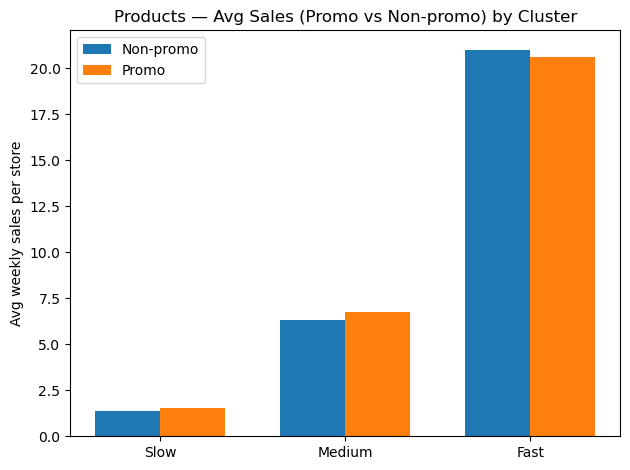

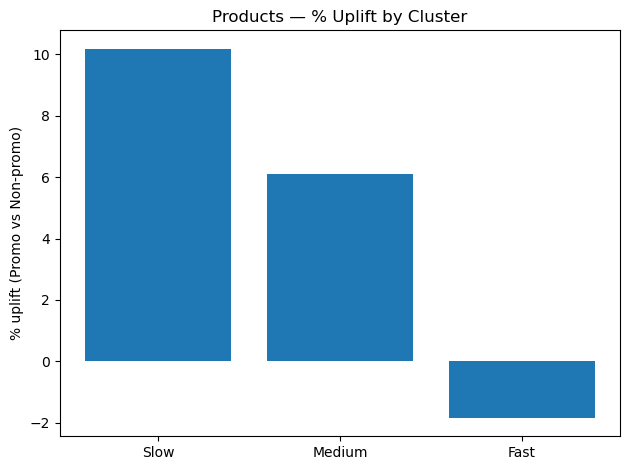

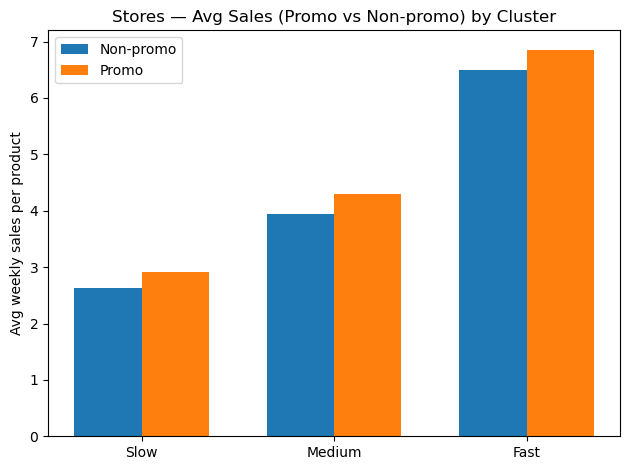

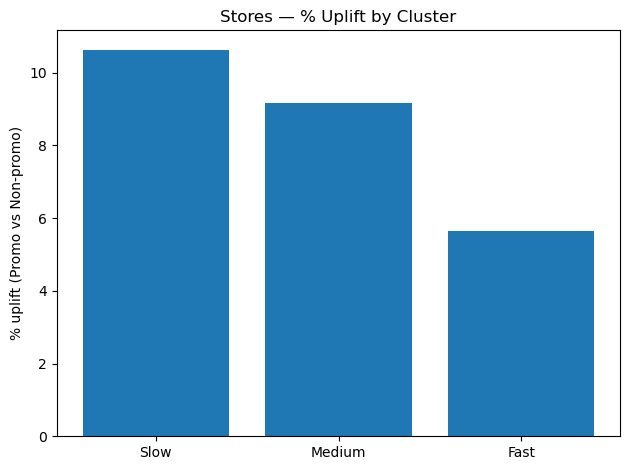

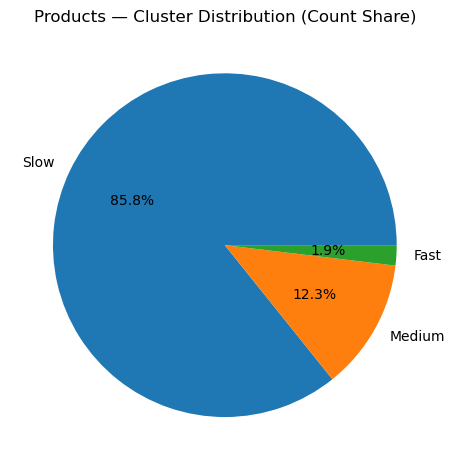

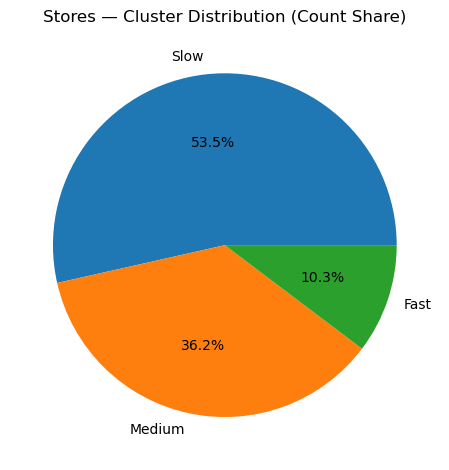

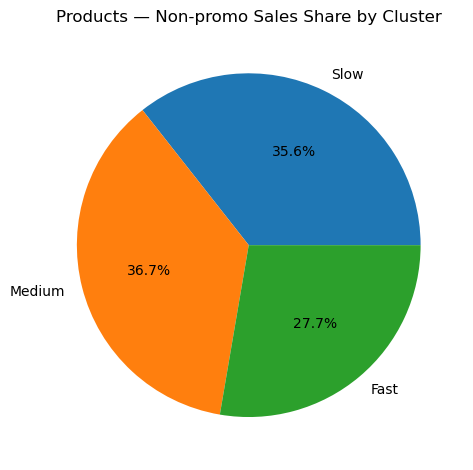

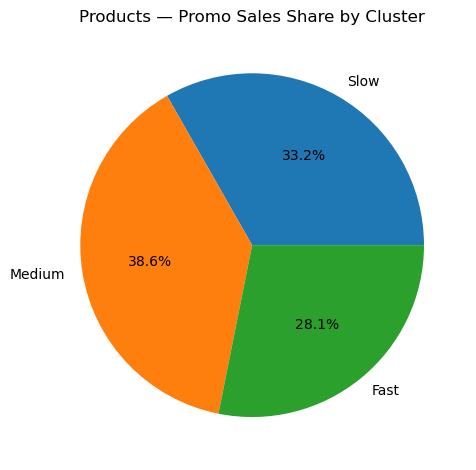

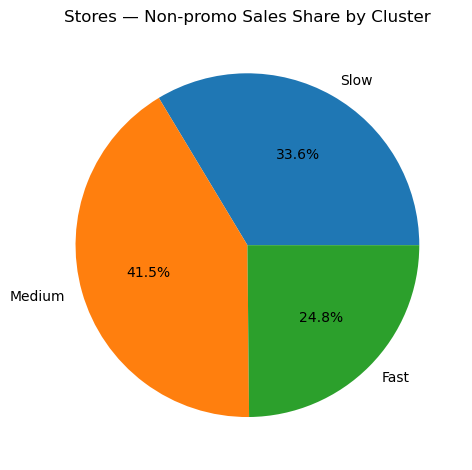

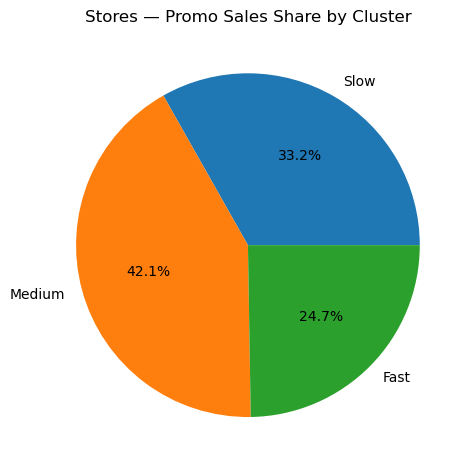

In [97]:
# FIXED single-block visualization (no file saves), string labels, one chart per figure (no subplots).
# Shows cluster-wise promo vs non-promo tables, bar charts, and pie charts
# comparing distributions and sales shares across clusters.
#
# Prereqs already in memory:
# - product_perf, store_perf (from STEP 3B)
# - product_promo_perf, store_promo_perf (from STEP 3C)
# - prod_compare, store_compare (optional; will be built if missing)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ---------- Build prod_compare / store_compare if missing ----------
g = globals()

if "prod_compare" not in g:
    if "product_perf" in g and "product_promo_perf" in g:
        prod_compare = (
            product_perf[["ProductCode", "avg_weekly_sales_per_store",
                          "n_store_weeks_nonpromo", "total_nonpromo_sales", "cluster_label"]]
            .merge(
                product_promo_perf[["ProductCode", "avg_weekly_sales_per_store_promo",
                                    "n_store_weeks_promo", "total_promo_sales"]],
                on="ProductCode", how="left"
            )
        )
        prod_compare["diff_avg"]  = prod_compare["avg_weekly_sales_per_store_promo"] - prod_compare["avg_weekly_sales_per_store"]
        prod_compare["ratio_avg"] = (
            prod_compare["avg_weekly_sales_per_store_promo"] /
            prod_compare["avg_weekly_sales_per_store"].replace({0: np.nan})
        )
    else:
        raise RuntimeError("Missing inputs to build prod_compare. Run STEP 3B/3C first.")

if "store_compare" not in g:
    if "store_perf" in g and "store_promo_perf" in g:
        store_compare = (
            store_perf[["StoreCode", "avg_weekly_sales_per_product",
                        "n_product_weeks_nonpromo", "total_nonpromo_sales", "cluster_label"]]
            .merge(
                store_promo_perf[["StoreCode", "avg_weekly_sales_per_product_promo",
                                  "n_product_weeks_promo", "total_promo_sales"]],
                on="StoreCode", how="left"
            )
        )
        store_compare["diff_avg"]  = store_compare["avg_weekly_sales_per_product_promo"] - store_compare["avg_weekly_sales_per_product"]
        store_compare["ratio_avg"] = (
            store_compare["avg_weekly_sales_per_product_promo"] /
            store_compare["avg_weekly_sales_per_product"].replace({0: np.nan})
        )
    else:
        raise RuntimeError("Missing inputs to build store_compare. Run STEP 3B/3C first.")

# ---------- Cluster summaries (means, % uplift, sales totals for pies) ----------
prod_summary = (
    prod_compare.groupby("cluster_label", dropna=False)
    .agg(
        n_products=("ProductCode", "count"),
        nonpromo_avg=("avg_weekly_sales_per_store", "mean"),
        promo_avg=("avg_weekly_sales_per_store_promo", "mean"),
        nonpromo_sales_total=("total_nonpromo_sales","sum"),
        promo_sales_total=("total_promo_sales","sum")
    )
    .assign(
        uplift_abs=lambda d: d["promo_avg"] - d["nonpromo_avg"],
        uplift_pct=lambda d: (d["promo_avg"] / d["nonpromo_avg"].replace({0: np.nan}) - 1.0) * 100
    )
)

store_summary = (
    store_compare.groupby("cluster_label", dropna=False)
    .agg(
        n_stores=("StoreCode", "count"),
        nonpromo_avg=("avg_weekly_sales_per_product", "mean"),
        promo_avg=("avg_weekly_sales_per_product_promo", "mean"),
        nonpromo_sales_total=("total_nonpromo_sales","sum"),
        promo_sales_total=("total_promo_sales","sum")
    )
    .assign(
        uplift_abs=lambda d: d["promo_avg"] - d["nonpromo_avg"],
        uplift_pct=lambda d: (d["promo_avg"] / d["nonpromo_avg"].replace({0: np.nan}) - 1.0) * 100
    )
)

# Order clusters (ensure consistent order)
order_items = ["Slow","Medium","Fast"]
order_stores = ["Slow","Medium","Fast"]
prod_summary = prod_summary.reindex(order_items)
store_summary = store_summary.reindex(order_stores)

# ---------- Pretty print tables ----------
def _fmt(df):
    out = df.copy()
    if "n_products" in out: out["n_products"] = out["n_products"].astype("Int64")
    if "n_stores" in out:   out["n_stores"]   = out["n_stores"].astype("Int64")
    for c in ["nonpromo_avg","promo_avg","uplift_abs"]:
        if c in out: out[c] = out[c].round(2)
    if "uplift_pct" in out: out["uplift_pct"] = out["uplift_pct"].round(1)
    return out

print("=== Product clusters — Promo vs Non-promo ===")
display(_fmt(prod_summary))
print("\n=== Store clusters — Promo vs Non-promo ===")
display(_fmt(store_summary))

# ---------- Charts (one chart per figure; no explicit colors/styles) ----------
# 1) Products — Avg sales (promo vs non-promo)
plt.figure()
x = np.arange(len(prod_summary.index))
w = 0.35
plt.bar(x - w/2, prod_summary["nonpromo_avg"], w, label="Non-promo")
plt.bar(x + w/2, prod_summary["promo_avg"], w, label="Promo")
plt.xticks(x, prod_summary.index.astype(str))
plt.ylabel("Avg weekly sales per store")
plt.title("Products — Avg Sales (Promo vs Non-promo) by Cluster")
plt.legend()
plt.tight_layout()
plt.show()

# 2) Products — % uplift
plt.figure()
plt.bar(range(len(prod_summary.index)), prod_summary["uplift_pct"])
plt.xticks(range(len(prod_summary.index)), prod_summary.index.astype(str))
plt.ylabel("% uplift (Promo vs Non-promo)")
plt.title("Products — % Uplift by Cluster")
plt.tight_layout()
plt.show()

# 3) Stores — Avg sales (promo vs non-promo)
plt.figure()
x = np.arange(len(store_summary.index))
w = 0.35
plt.bar(x - w/2, store_summary["nonpromo_avg"], w, label="Non-promo")
plt.bar(x + w/2, store_summary["promo_avg"], w, label="Promo")
plt.xticks(x, store_summary.index.astype(str))
plt.ylabel("Avg weekly sales per product")
plt.title("Stores — Avg Sales (Promo vs Non-promo) by Cluster")
plt.legend()
plt.tight_layout()
plt.show()

# 4) Stores — % uplift
plt.figure()
plt.bar(range(len(store_summary.index)), store_summary["uplift_pct"])
plt.xticks(range(len(store_summary.index)), store_summary.index.astype(str))
plt.ylabel("% uplift (Promo vs Non-promo)")
plt.title("Stores — % Uplift by Cluster")
plt.tight_layout()
plt.show()

# 5) Products — Cluster distribution (counts)
plt.figure()
plt.pie(prod_summary["n_products"].fillna(0), labels=prod_summary.index.astype(str), autopct="%1.1f%%")
plt.title("Products — Cluster Distribution (Count Share)")
plt.tight_layout()
plt.show()

# 6) Stores — Cluster distribution (counts)
plt.figure()
plt.pie(store_summary["n_stores"].fillna(0), labels=store_summary.index.astype(str), autopct="%1.1f%%")
plt.title("Stores — Cluster Distribution (Count Share)")
plt.tight_layout()
plt.show()

# 7) Products — Sales share by cluster (Non-promo)
plt.figure()
plt.pie(prod_summary["nonpromo_sales_total"].fillna(0), labels=prod_summary.index.astype(str), autopct="%1.1f%%")
plt.title("Products — Non-promo Sales Share by Cluster")
plt.tight_layout()
plt.show()

# 8) Products — Sales share by cluster (Promo)
plt.figure()
plt.pie(prod_summary["promo_sales_total"].fillna(0), labels=prod_summary.index.astype(str), autopct="%1.1f%%")
plt.title("Products — Promo Sales Share by Cluster")
plt.tight_layout()
plt.show()

# 9) Stores — Sales share by cluster (Non-promo)
plt.figure()
plt.pie(store_summary["nonpromo_sales_total"].fillna(0), labels=store_summary.index.astype(str), autopct="%1.1f%%")
plt.title("Stores — Non-promo Sales Share by Cluster")
plt.tight_layout()
plt.show()

# 10) Stores — Sales share by cluster (Promo)
plt.figure()
plt.pie(store_summary["promo_sales_total"].fillna(0), labels=store_summary.index.astype(str), autopct="%1.1f%%")
plt.title("Stores — Promo Sales Share by Cluster")
plt.tight_layout()
plt.show()


In [103]:
#BONUS

C:\Users\kaant\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\kaant\AppData\Local\Temp\ipykernel_19620\2183532422.py:26: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '['SlowPromo' 'SlowPromo' 'SlowPromo' 'SlowPromo' 'SlowPromo' 'SlowPromo'
 'SlowPromo' 'SlowPromo' 'SlowPromo' 'SlowPromo' 'SlowPromo' 'SlowPromo'
 'SlowPromo' 'SlowPromo' 'SlowPromo' 'SlowPromo' 'SlowPromo' 'SlowPromo'
 'SlowPromo' 'SlowPromo' 'SlowPromo' 'SlowPromo' 'SlowPromo' 'SlowPromo'
 'SlowPromo' 'SlowPromo' 'SlowPromo' 'SlowPromo' 'SlowPromo' 'SlowPromo'
 'SlowPromo' 'SlowPromo' 'SlowPromo' 'SlowPromo' 'SlowPromo' 'SlowPromo'
 'SlowPromo' 'SlowPromo' 'SlowPromo' 'SlowPromo' 'SlowPromo' 'SlowPromo'
 'Sl

cluster_label_promoSpeed centers (orig units): [ 1.547  6.76  19.642]

[PRODUCTS] Promo-speed cluster counts:
cluster_label_promoSpeed
SlowPromo      258
MediumPromo     36
NaN             16
FastPromo        7
Name: count, dtype: int64

[PRODUCTS] Transition matrix (counts):
cluster_label_promoSpeed  SlowPromo  MediumPromo  FastPromo
cluster_label                                              
Slow                            253            2          0
Medium                            4           34          1
Fast                              0            0          6

[PRODUCTS] Transition matrix (row %):
cluster_label_promoSpeed  SlowPromo  MediumPromo  FastPromo
cluster_label                                              
Slow                           99.2          0.8        0.0
Medium                         10.3         87.2        2.6
Fast                            0.0          0.0      100.0

[PRODUCTS] Uplift by transition (mean ratio & diff):
                              

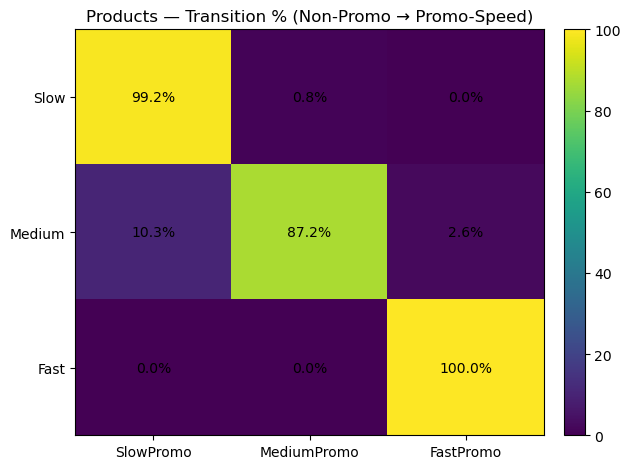

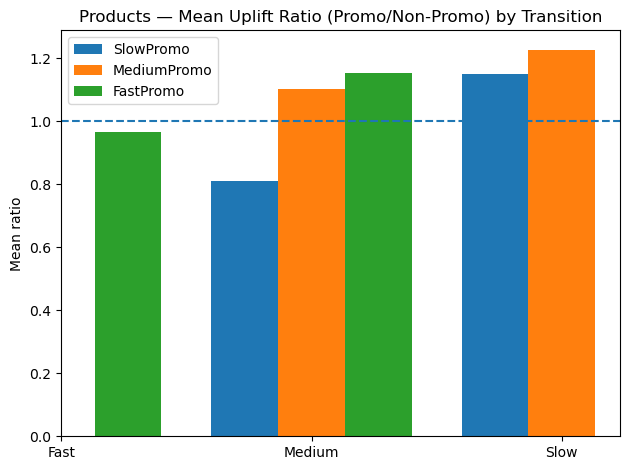

C:\Users\kaant\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
C:\Users\kaant\AppData\Local\Temp\ipykernel_19620\2183532422.py:26: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '['SlowPromo' 'FastPromo' 'SlowPromo' 'MediumPromo' 'SlowPromo'
 'MediumPromo' 'MediumPromo' 'SlowPromo' 'MediumPromo' 'SlowPromo'
 'SlowPromo' 'SlowPromo' 'SlowPromo' 'FastPromo' 'SlowPromo' 'SlowPromo'
 'MediumPromo' 'SlowPromo' 'SlowPromo' 'FastPromo' 'MediumPromo'
 'SlowPromo' 'MediumPromo' 'MediumPromo' 'SlowPromo' 'MediumPromo'
 'SlowPromo' 'SlowPromo' 'MediumPromo' 'MediumPromo' 'SlowPromo'
 'SlowPromo' 'MediumPromo' 'SlowPromo' 'MediumPromo' 'MediumPromo'
 'MediumPromo' 'MediumPromo' 'SlowPromo' 'Medium

cluster_label_promoSpeed centers (orig units): [2.76  4.311 7.061]

[STORES] Promo-speed cluster counts:
cluster_label_promoSpeed
SlowPromo      167
MediumPromo    134
FastPromo       35
NaN              4
Name: count, dtype: int64

[STORES] Transition matrix (counts):
cluster_label_promoSpeed  SlowPromo  MediumPromo  FastPromo
cluster_label                                              
Slow                            144           34          0
Medium                           23           92          8
Fast                              0            8         27

[STORES] Transition matrix (row %):
cluster_label_promoSpeed  SlowPromo  MediumPromo  FastPromo
cluster_label                                              
Slow                           80.9         19.1        0.0
Medium                         18.7         74.8        6.5
Fast                            0.0         22.9       77.1

[STORES] Uplift by transition (mean ratio & diff):
                                         

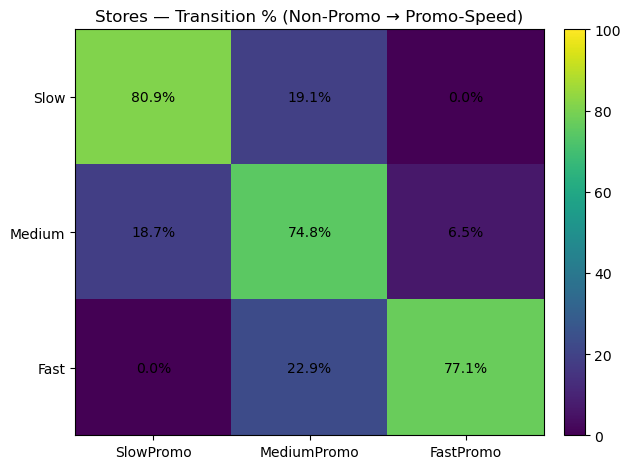

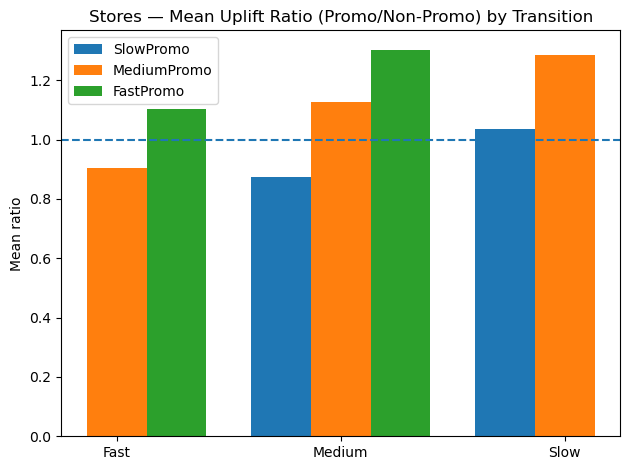

In [105]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# ============= UTILITIES =============
def ensure_promo_speed_labels(df, feature_col, label_col):
    """df: DataFrame (product_promo_perf or store_promo_perf)
       feature_col: avg promo speed column name
       label_col: output label col (SlowPromo/MediumPromo/FastPromo)"""
    if label_col in df.columns and df[label_col].notna().any():
        return df  # already present
    mask = df[feature_col].notna()
    X = df.loc[mask, [feature_col]].values
    if X.size == 0:
        df[label_col] = np.nan
        return df
    sc = StandardScaler().fit(X)
    km = KMeans(n_clusters=3, random_state=42, n_init=20).fit(sc.transform(X))
    centers_orig = sc.inverse_transform(km.cluster_centers_).ravel()
    order = np.argsort(centers_orig)
    label_map = {order[0]:"SlowPromo", order[1]:"MediumPromo", order[2]:"FastPromo"}
    labels = pd.Series(km.labels_, index=df.index[mask]).map(label_map)
    df[label_col] = np.nan
    df.loc[mask, label_col] = labels
    print(f"{label_col} centers (orig units):", np.round(centers_orig[order], 3))
    return df

def heatmap_matplotlib(mat, row_labels, col_labels, title, vmin=0, vmax=100):
    """Simple heatmap with annotations using matplotlib only."""
    plt.figure()
    img = plt.imshow(mat, aspect='auto', vmin=vmin, vmax=vmax)
    plt.colorbar(img, fraction=0.046, pad=0.04)
    plt.xticks(np.arange(len(col_labels)), [str(c) for c in col_labels], rotation=0)
    plt.yticks(np.arange(len(row_labels)), [str(r) for r in row_labels])
    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            val = mat[i, j]
            if not np.isnan(val):
                plt.text(j, i, f"{val:.1f}%", ha='center', va='center')
    plt.title(title)
    plt.tight_layout()
    plt.show()

def grouped_bar_from_pivot(piv, title, ylabel, baseline=1.0):
    """Grouped bar (x = rows, groups = columns)."""
    rows = [str(r) for r in piv.index]
    cols = [str(c) for c in piv.columns]
    x = np.arange(len(rows))
    w = 0.8 / max(1, len(cols))
    plt.figure()
    for k, c in enumerate(cols):
        plt.bar(x + (k - (len(cols)-1)/2)*w, piv[c].values, width=w, label=c)
    plt.xticks(x, rows)
    if baseline is not None:
        plt.axhline(baseline, linestyle="--")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

# Desired cluster order
nonpromo_order = ["Slow","Medium","Fast"]
promospeed_order = ["SlowPromo","MediumPromo","FastPromo"]

# ============= PRODUCTS =============
# ensure promo-speed labels
product_promo_perf = ensure_promo_speed_labels(
    product_promo_perf,
    feature_col="avg_weekly_sales_per_store_promo",
    label_col="cluster_label_promoSpeed"
)

# merge non-promo & promo features + labels
prod = product_perf.merge(
    product_promo_perf[["ProductCode","avg_weekly_sales_per_store_promo","cluster_label_promoSpeed"]],
    on="ProductCode", how="left"
)

# metrics
prod["ratio_avg"] = prod["avg_weekly_sales_per_store_promo"] / prod["avg_weekly_sales_per_store"].replace({0:np.nan})
prod["diff_avg"]  = prod["avg_weekly_sales_per_store_promo"] - prod["avg_weekly_sales_per_store"]

# counts of promo-speed clusters
print("\n[PRODUCTS] Promo-speed cluster counts:")
print(prod["cluster_label_promoSpeed"].value_counts(dropna=False))

# crosstab (counts & row %)
prod_ct_counts = pd.crosstab(
    prod["cluster_label"].astype("string"),
    prod["cluster_label_promoSpeed"].astype("string")
).reindex(index=nonpromo_order, columns=promospeed_order)

prod_ct_rowpct = prod_ct_counts.div(prod_ct_counts.sum(axis=1), axis=0) * 100

print("\n[PRODUCTS] Transition matrix (counts):")
print(prod_ct_counts.fillna(0).astype(int))
print("\n[PRODUCTS] Transition matrix (row %):")
print(prod_ct_rowpct.round(1).fillna(0))

# uplift summary by transition
prod_uplift = (prod
    .groupby(["cluster_label","cluster_label_promoSpeed"], dropna=False)
    .agg(n=("ProductCode","count"),
         mean_ratio=("ratio_avg","mean"),
         mean_diff=("diff_avg","mean"))
    .reindex(index=pd.MultiIndex.from_product([nonpromo_order, promospeed_order], names=["cluster_label","cluster_label_promoSpeed"]))
)

print("\n[PRODUCTS] Uplift by transition (mean ratio & diff):")
print(prod_uplift.round(3).fillna(0))

# visuals
# heatmap of row %
heatmap_matplotlib(
    prod_ct_rowpct.reindex(index=nonpromo_order, columns=promospeed_order).values,
    row_labels=nonpromo_order, col_labels=promospeed_order,
    title="Products — Transition % (Non-Promo → Promo-Speed)"
)

# grouped bar: mean uplift ratio by non-promo cluster, bars=promo-speed
prod_ratio_piv = prod_uplift["mean_ratio"].unstack().reindex(columns=promospeed_order)
grouped_bar_from_pivot(
    prod_ratio_piv,
    title="Products — Mean Uplift Ratio (Promo/Non-Promo) by Transition",
    ylabel="Mean ratio", baseline=1.0
)

# ============= STORES =============
# ensure promo-speed labels
store_promo_perf = ensure_promo_speed_labels(
    store_promo_perf,
    feature_col="avg_weekly_sales_per_product_promo",
    label_col="cluster_label_promoSpeed"
)

# merge
st = store_perf.merge(
    store_promo_perf[["StoreCode","avg_weekly_sales_per_product_promo","cluster_label_promoSpeed"]],
    on="StoreCode", how="left"
)

# metrics
st["ratio_avg"] = st["avg_weekly_sales_per_product_promo"] / st["avg_weekly_sales_per_product"].replace({0:np.nan})
st["diff_avg"]  = st["avg_weekly_sales_per_product_promo"] - st["avg_weekly_sales_per_product"]

# counts
print("\n[STORES] Promo-speed cluster counts:")
print(st["cluster_label_promoSpeed"].value_counts(dropna=False))

# crosstab
st_ct_counts = pd.crosstab(
    st["cluster_label"].astype("string"),
    st["cluster_label_promoSpeed"].astype("string")
).reindex(index=nonpromo_order, columns=promospeed_order)

st_ct_rowpct = st_ct_counts.div(st_ct_counts.sum(axis=1), axis=0) * 100

print("\n[STORES] Transition matrix (counts):")
print(st_ct_counts.fillna(0).astype(int))
print("\n[STORES] Transition matrix (row %):")
print(st_ct_rowpct.round(1).fillna(0))

# uplift summary
st_uplift = (st
    .groupby(["cluster_label","cluster_label_promoSpeed"], dropna=False)
    .agg(n=("StoreCode","count"),
         mean_ratio=("ratio_avg","mean"),
         mean_diff=("diff_avg","mean"))
    .reindex(index=pd.MultiIndex.from_product([nonpromo_order, promospeed_order], names=["cluster_label","cluster_label_promoSpeed"]))
)

print("\n[STORES] Uplift by transition (mean ratio & diff):")
print(st_uplift.round(3).fillna(0))

# visuals
heatmap_matplotlib(
    st_ct_rowpct.reindex(index=nonpromo_order, columns=promospeed_order).values,
    row_labels=nonpromo_order, col_labels=promospeed_order,
    title="Stores — Transition % (Non-Promo → Promo-Speed)"
)

st_ratio_piv = st_uplift["mean_ratio"].unstack().reindex(columns=promospeed_order)
grouped_bar_from_pivot(
    st_ratio_piv,
    title="Stores — Mean Uplift Ratio (Promo/Non-Promo) by Transition",
    ylabel="Mean ratio", baseline=1.0
)


In [106]:
import numpy as np
import pandas as pd

def pct(x): 
    return "—" if pd.isna(x) else f"{x:.1f}%"

def ratio_to_pct(r):
    return "—" if pd.isna(r) else f"{(r-1.0)*100:.1f}%"

def safe_mean(s):
    return np.nan if len(s)==0 else np.nanmean(s)

# ===== PRODUCTS: headline summary =====
print("=== PRODUCTS — Headline Summary ===")

# 1) Non-promo cluster bazında genel uplift
for cl in ["Slow","Medium","Fast"]:
    sub = prod[prod["cluster_label"]==cl]
    mean_ratio = safe_mean(sub["ratio_avg"])
    mean_diff  = safe_mean(sub["diff_avg"])
    n = sub.shape[0]
    print(f"- {cl}: avg uplift = {ratio_to_pct(mean_ratio)} (abs: {0 if pd.isna(mean_diff) else round(mean_diff,2)}), n={n}")

# 2) En yüksek uplift veren non-promo cluster (ratio)
grp = (prod.groupby("cluster_label")["ratio_avg"].mean().dropna())
if len(grp)>0:
    best_non = grp.idxmax()
    print(f"→ En yüksek ortalama uplift non-promo '{best_non}' kümesinde: {ratio_to_pct(grp.max())}")

# 3) Geçiş matrisi — non-promo Slow için en baskın promo-speed nereye?
row = prod_ct_rowpct.loc["Slow"].dropna() if "Slow" in prod_ct_rowpct.index else None
if row is not None and row.size>0:
    dest = row.idxmax()
    print(f"→ Non-promo Slow ürünlerin en yaygın promo-speed geçişi: {dest} ({pct(row.max())})")

# 4) Uplift by transition — en yüksek ratio (yeterli n ile)
tmp = prod_uplift.reset_index()
tmp = tmp[tmp["n"]>=5]  # çok küçük hücreleri filtrele (eşiği istersen değiştir)
if tmp.shape[0]>0:
    r = tmp.loc[tmp["mean_ratio"].idxmax()]
    print(f"→ En yüksek uplift (geçiş): {r['cluster_label']} → {r['cluster_label_promoSpeed']} | ratio={ratio_to_pct(r['mean_ratio'])}, diff={round(r['mean_diff'],2)}, n={int(r['n'])}")

print("\n")

# ===== STORES: headline summary =====
print("=== STORES — Headline Summary ===")

# 1) Non-promo cluster bazında genel uplift
for cl in ["Slow","Medium","Fast"]:
    sub = st[st["cluster_label"]==cl]
    mean_ratio = safe_mean(sub["ratio_avg"])
    mean_diff  = safe_mean(sub["diff_avg"])
    n = sub.shape[0]
    print(f"- {cl}: avg uplift = {ratio_to_pct(mean_ratio)} (abs: {0 if pd.isna(mean_diff) else round(mean_diff,2)}), n={n}")

# 2) En yüksek uplift veren non-promo cluster
grp = (st.groupby("cluster_label")["ratio_avg"].mean().dropna())
if len(grp)>0:
    best_non = grp.idxmax()
    print(f"→ En yüksek ortalama uplift non-promo '{best_non}' mağaza kümesinde: {ratio_to_pct(grp.max())}")

# 3) Geçiş matrisi — non-promo Medium için en baskın promo-speed nereye?
row = st_ct_rowpct.loc["Medium"].dropna() if "Medium" in st_ct_rowpct.index else None
if row is not None and row.size>0:
    dest = row.idxmax()
    print(f"→ Non-promo Medium mağazaların en yaygın promo-speed geçişi: {dest} ({pct(row.max())})")

# 4) Uplift by transition — en yüksek ratio (yeterli n ile)
tmp = st_uplift.reset_index()
tmp = tmp[tmp["n"]>=5]
if tmp.shape[0]>0:
    r = tmp.loc[tmp["mean_ratio"].idxmax()]
    print(f"→ En yüksek uplift (geçiş): {r['cluster_label']} → {r['cluster_label_promoSpeed']} | ratio={ratio_to_pct(r['mean_ratio'])}, diff={round(r['mean_diff'],2)}, n={int(r['n'])}")


=== PRODUCTS — Headline Summary ===
- Slow: avg uplift = 15.2% (abs: 0.08), n=271
- Medium: avg uplift = 7.4% (abs: 0.39), n=39
- Fast: avg uplift = -3.2% (abs: -0.39), n=6
→ En yüksek ortalama uplift non-promo 'Slow' kümesinde: 15.2%
→ Non-promo Slow ürünlerin en yaygın promo-speed geçişi: SlowPromo (99.2%)
→ En yüksek uplift (geçiş): Slow → SlowPromo | ratio=15.1%, diff=0.08, n=253


=== STORES — Headline Summary ===
- Slow: avg uplift = 8.2% (abs: 0.22), n=182
- Medium: avg uplift = 9.1% (abs: 0.36), n=123
- Fast: avg uplift = 5.7% (abs: 0.37), n=35
→ En yüksek ortalama uplift non-promo 'Medium' mağaza kümesinde: 9.1%
→ Non-promo Medium mağazaların en yaygın promo-speed geçişi: MediumPromo (74.8%)
→ En yüksek uplift (geçiş): Medium → FastPromo | ratio=30.3%, diff=1.38, n=8
